In [37]:
experiment_file = '../experiments/output/zigzag_line_10_to_90/2023_12_08_111_32/experiment_result.json'

## Overview

In [38]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [39]:
with open(experiment_file, 'r') as fp:
    data = json.load(fp)

FileNotFoundError: [Errno 2] No such file or directory: '../experiments/output/zigzag_line_10_to_90/2023_12_08_111_32/experiment_result.json'

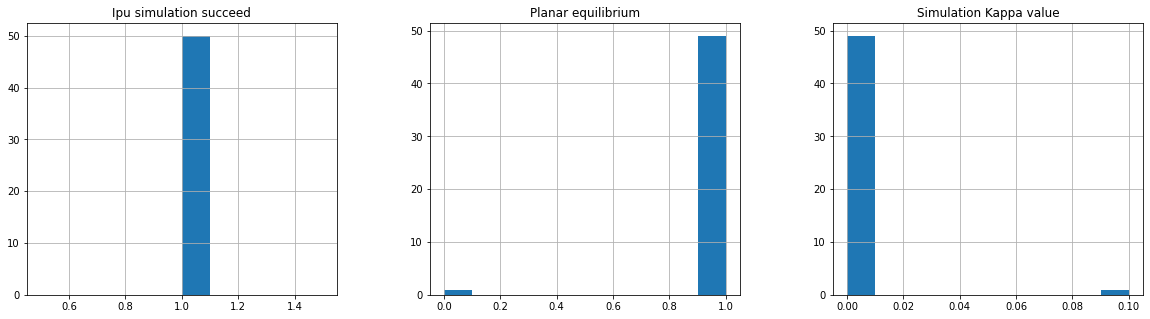

In [40]:
df = pd.DataFrame(data['data'])
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 5))
a = (df.hist('Ipu simulation succeed', ax = axes[0]), df.hist('Planar equilibrium', ax = axes[1]), df.hist('Simulation Kappa value', ax = axes[2]))

In [5]:
list(df.loc[df['Planar equilibrium'] == 0]['name'])

[]

In [15]:
valid_tags = np.array(df['name'][df['Planar equilibrium'] == 1])

In [16]:
# grid_size = [0, 0, 0]

# for i, entry in enumerate(data['pattern_parameters']):
#     grid_size[i] = len(entry['values'])


In [17]:
# def get_largest_box_of_valid_data_point(data, grid_size):
#     param_grid = np.multiply(np.array(df['Planar equilibrium']).reshape(grid_size), np.array(df['Ipu simulation succeed']).reshape(grid_size))
#     import time

#     box_sizes = []
#     box_entries = []
#     curr_max = 0
#     for i in range(grid_size[0]):
#         for j in range(grid_size[1]):
#             for k in range(grid_size[2]):
#                 for i1 in range(grid_size[0] + 1)[i+1:]:
#                     for j1 in range(grid_size[1] + 1)[j+1:]:
#                         for k1 in range(grid_size[2] + 1)[k+1:]:
#                             if 0 in param_grid[i:i1, j:j1, k:k1]:
#                                 box_size = 0
#                                 break
#                             else:
#                                 box_size = (i1 - i) * (j1 - j) * (k1 - k)
#                                 box_entries.append([i, i1, j, j1, k, k1])
#                                 box_sizes.append(box_size)
#                                 curr_max = max(curr_max, box_size)

#     largest_box = box_entries[np.argmax(box_sizes)]

#     box_sizes[np.argmax(box_sizes)]
#     return largest_box

In [18]:
# largest_box = get_largest_box_of_valid_data_point(data, grid_size)

In [19]:
# valid_tags = np.array(df['name']).reshape(grid_size)[largest_box[0]:largest_box[1], largest_box[2]:largest_box[3],largest_box[4]:largest_box[5]].flatten()

In [20]:
# stiffness_tags = list(df.loc[df['Planar equilibrium'] > 0]['name'])

In [21]:
"number of valid point in the box", len(valid_tags), "total number of experiment", np.product(grid_size)

('number of valid point in the box', 50, 'total number of experiment', 0)

## Analysis

In [22]:
import itertools
import numpy as np

In [25]:
import importlib
import visualize_stiffness
importlib.reload(visualize_stiffness)

<module 'visualize_stiffness' from '/Users/yren/Develop/Inflatables/python/periodic_patches/Visualization/visualize_stiffness.py'>

In [ ]:
../experiments/output/zigzag_line_10_to_90/2023_12_08_14_51/

In [ ]:
stiffness_path = '../experiments/output/zigzag_line_10_to_90/2023_12_04_10_34/'


In [31]:
kappa_path = None

In [32]:
bending_stiffness_data, stretching_stiffness_data, scale_factor_data, used_tags = visualize_stiffness.plot_all_data(kappa_path, stiffness_path, name, valid_tags, plot_data = False)

NameError: name 'stiffness_path' is not defined

In [26]:
iteration_tags = list(df['name'])

data_info = [[data['configuration']['base_folder'], data['configuration']['name'], iteration_tags]]
i = 0
len(iteration_tags)



# data = visualize_stiffness.plot_all_data(None, data_info[i][0], data_info[i][1], used_tags)

scale_factor_data = visualize_stiffness.get_scale_factor(data_info[i][0], data_info[i][1], valid_tags)

min_stiffness = visualize_stiffness.get_extreme_stiffness(data_info[i][0], data_info[i][1], valid_tags, use_min = True)
max_stiffness = visualize_stiffness.get_extreme_stiffness(data_info[i][0], data_info[i][1], valid_tags, use_min = False)

In [27]:
data['configuration']['base_folder']

'/Users/yren/Develop/Inflatables/python/periodic_patches/experiments/output/zigzag_line_10_to_90/2023_12_04_10_34'

In [28]:
valid_tags[np.argmin(min_stiffness)], min(min_stiffness)

ValueError: attempt to get argmin of an empty sequence

In [ ]:
parameters = [entry['values'] for entry in data['pattern_parameters']]

In [ ]:
parameters_range = [max(parameters[i]) - min(parameters[i]) for i in range(len(parameters))]

In [ ]:
normalize_parameters = [lambda x, min_val =  min(parameters[i]), range_val = parameters_range[i]: (x - min_val) / range_val for i in range(len(parameters))]

In [ ]:
normalize_parameters[0](0.1)

In [ ]:
used_parameters = np.array([[normalize_parameters[i](float(entry.split('_')[i])) for entry in valid_tags] for i in range(len(parameters))]).T

In [ ]:
import matplotlib.cm as cm
import matplotlib as mpl

In [ ]:
norm = mpl.colors.Normalize()

In [ ]:
import polyscope as ps

In [ ]:
norm.autoscale(A = max_stiffness)

In [ ]:
norm(max_stiffness)

In [ ]:
cm.Reds(norm(max_stiffness))[:, :3].shape

In [ ]:
# # Initialize polyscope
# ps.init()

# ### Register a point cloud
# # `my_points` is a Nx3 numpy array
# ps_cloud = ps.register_point_cloud("my points", used_parameters, radius = 0.02, )
# ps_cloud.add_color_quantity("min stiffness", values = cm.Reds(norm(max_stiffness))[:, :3], enabled = True)
# # View the point cloud and mesh we just registered in the 3D UI
# ps.show()

In [ ]:
import numpy.linalg as la

# Need to plot the patches over the min and max scale factors, so we can get the polygon that constrain the singular values
# The scale factors we are considering during the parametrization are from the flattening, so it's the change from the inflated state to the fabricated state, hence we need to take one over the factors we have from the average deformation gradient from homogenization.
max_scale_factor = 1 / np.array(scale_factor_data)[:, 0]
min_scale_factor = 1 / np.array(scale_factor_data)[:, 1]

fig, ax = plt.subplots(figsize = (15, 15))

# plt.scatter(x_scale_factor, y_scale_factor, label = data_info[i][1], s = 50, alpha = 0.3)
# plt.scatter(y_scale_factor, x_scale_factor, label = data_info[i][1], s = 50, alpha = 0.3)
plt.scatter(min_scale_factor, max_scale_factor, label = data_info[i][1], s = 50, alpha = 0.8, c = min_stiffness)
# plt.scatter(y_scale_factor, x_scale_factor, label = data_info[i][1], s = 50, alpha = 0.8, c = min_stiffness)

inequality_constraints = []
# convex boundaries:
x = np.linspace(1., 1.45, 100)

a = -1
b = 2.415

plt.plot(x, a * x + b, label = "1")

inequality_constraints.append([a, -1, b])


result = np.linalg.solve(np.array([[1.282, 1], [1, 1]]), np.array([1.282, 1.5]))
a = result[0]
b = result[1]

x = np.linspace(1., 1.3, 100)


plt.plot(x, a * x + b, label = "2")
inequality_constraints.append([a, -1, b])


result = np.linalg.solve(np.array([[1.282, 1], [1.5, 1]]), np.array([1.282, 1.]))
a = result[0]
b = result[1]
x = np.linspace(1.25, 1.5, 100)


plt.plot(x, a * x + b, label = "3")
inequality_constraints.append([a, -1, b])


result = np.linalg.solve(np.array([[1.005, 1], [1.07, 1]]), np.array([1.5, 1.35]))
a = result[0]
b = result[1]

x = np.linspace(1, 1.1, 100)

plt.plot(x, a * x + b, label = "4")
inequality_constraints.append([a, -1, b])


result = np.linalg.solve(np.array([[1.5, 1], [1.35, 1]]), np.array([1.005, 1.07]))
a = result[0]
b = result[1]

x = np.linspace(1.3, 1.5, 100)

plt.plot(x, a * x + b, label = "5")
inequality_constraints.append([a, -1, b])


# fig.set_size_inches(12, 12)
ax.title.set_text("Scale factors")
plt.xlabel("min scale factors")
plt.ylabel("max scale factors")

# Plot x = y line
lims = [
np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
fig.tight_layout()
# plt.savefig('scale_factor_values_{}.png'.format(name), dpi = 300)